# Shape–Color dataset inspection

This notebook creates the three deterministic Phase A splits, checks their group counts, and saves/displays one example from each group. Run it with the working directory set to the `project/` directory.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from PIL import Image

candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "project",
]

PROJECT_ROOT = next(
    path for path in candidates
    if (path / "src").is_dir()
)

sys.path.insert(0, str(PROJECT_ROOT))

from src.data import create_splits, save_four_groups_figure

In [4]:
SEED = 42
splits = create_splits(seed=SEED)

for name, dataset in splits.items():
    counts = torch.bincount(dataset.groups, minlength=4).tolist()
    aligned_fraction = ((dataset.groups // 2) == (dataset.groups % 2)).float().mean().item()
    print(f'{name:14s} size={len(dataset):5d} groups={counts} aligned={aligned_fraction:.2%}')

train_biased   size=10000 groups=[4750, 250, 250, 4750] aligned=95.00%
val_biased     size= 2000 groups=[950, 50, 50, 950] aligned=95.00%
test_balanced  size= 4000 groups=[1000, 1000, 1000, 1000] aligned=50.00%


Saved to: /home/luisa-carvalhaes/UFMG/pesquisa/pruning-shortcuts-mechinterp/project/notebooks/outputs/sanity_check/four_groups.png


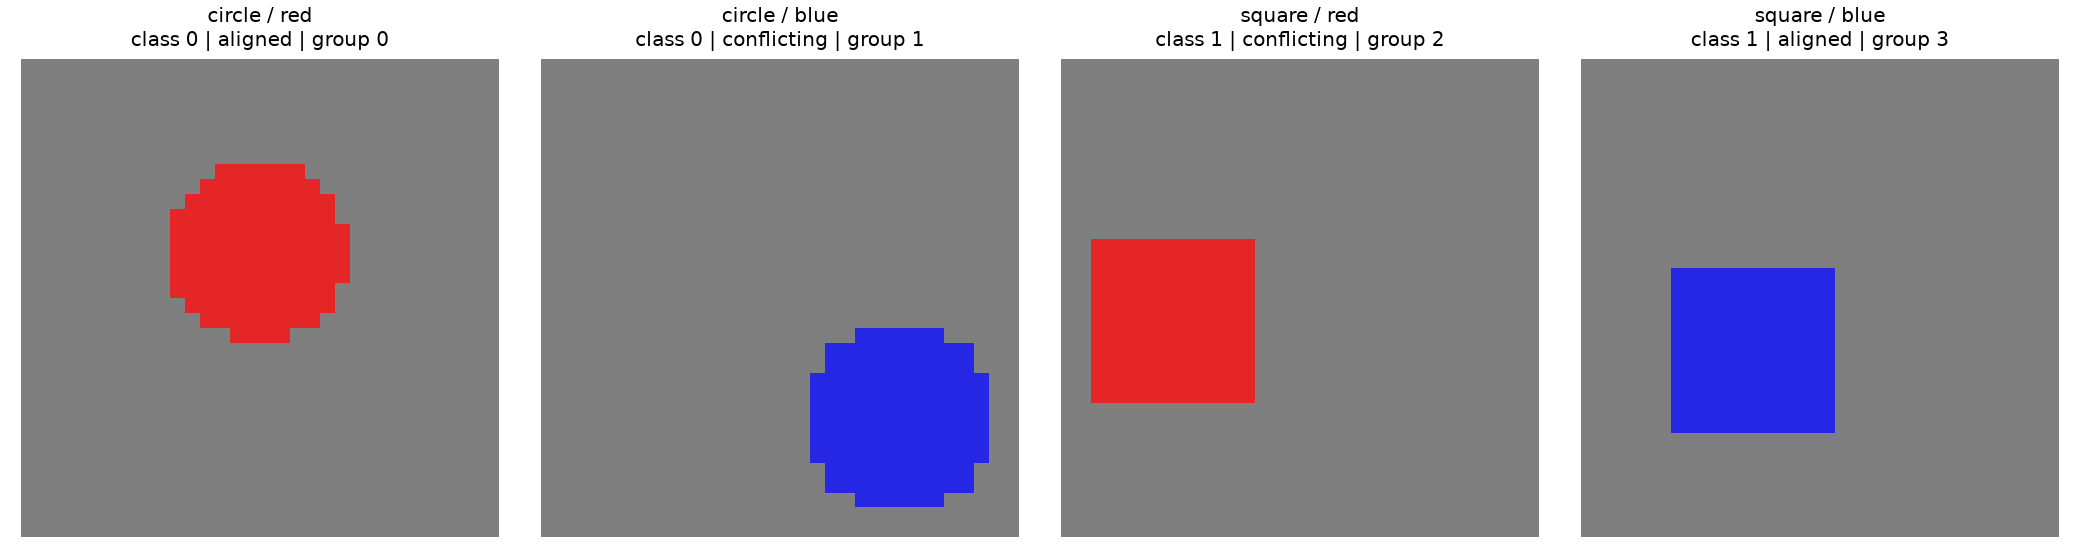

In [5]:
output_path = save_four_groups_figure(
    splits['test_balanced'],
    Path('outputs/sanity_check/four_groups.png'),
)
print(f'Saved to: {output_path.resolve()}')
display(Image.open(output_path))

Expected group meanings:

- group 0: red circle, class 0, aligned
- group 1: blue circle, class 0, conflicting
- group 2: red square, class 1, conflicting
- group 3: blue square, class 1, aligned